# 电影推荐系统模型对比实验

本 Notebook 用于完成课程要求中的“模型训练与评估”和“对比实验”部分。实验会对比两个基于物品的协同过滤模型：

- `baseline_numpy_item_cf`：`src/model.py` 中的 NumPy 手写余弦相似度基线模型。
- `sklearn_centered_item_cf`：`src/cf_recommender.py` 中使用 `scikit-learn` 计算余弦相似度，并加入用户均值中心化的改进模型。

为了保证对比公平，两个模型使用同一份训练集/测试集划分、同一批测试用户和同一套评价指标。

## 1. 环境准备与数据加载

加载项目源码、过滤后的用户-电影评分矩阵，并记录后续报告中可直接引用的实验设置。

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

project_root = Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cf_recommender import attach_movie_titles, load_movie_title_map
from src.evaluation import (
    BASELINE_ALGORITHM,
    SKLEARN_ALGORITHM,
    compare_models,
    load_filtered_matrix,
    recommend_for_user,
    sensitivity_analysis,
    train_test_split_matrix,
)

sns.set_theme(style='whitegrid')
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS', 'DejaVu Sans']

matrix = load_filtered_matrix()
n_users, n_items = matrix.shape
n_ratings = int(matrix.notna().sum().sum())
sparsity = 1 - n_ratings / (n_users * n_items)

experiment_config = {
    '数据集': 'MovieLens ml-latest-small',
    '过滤规则': '用户评分数 >= 30，电影评分数 >= 15',
    '矩阵规模': matrix.shape,
    '评分数量': n_ratings,
    '矩阵稀疏度': round(sparsity, 4),
    '测试集比例': 0.2,
    '随机种子': 42,
    '推荐列表长度 Top-N': 10,
    '相关电影阈值': 'rating >= 4.0',
}

print('项目根目录：', project_root)
display(pd.Series(experiment_config, name='取值'))
display(matrix.head())

项目根目录： D:\Movie-Recommender-System


数据集             MovieLens ml-latest-small
过滤规则              用户评分数 >= 30，电影评分数 >= 15
矩阵规模                          (475, 1617)
评分数量                                70454
矩阵稀疏度                              0.9083
测试集比例                                 0.2
随机种子                                   42
推荐列表长度 Top-N                           10
相关电影阈值                      rating >= 4.0
Name: 取值, dtype: object

,1,2,3,5,6,7,10,11,12,14,...,138036,139385,142488,148626,152081,158238,164179,166528,168252,176371
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,4.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,4.0,5.0,5.0,4.0,4.0,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,4.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. 固定训练集与测试集

按用户维度随机抽取一部分已评分电影作为测试集，其余评分作为训练集。这样可以模拟“隐藏用户一部分历史评分，再检查模型能否预测出来”的评估过程。

默认只选取前 20 个有测试评分的用户进行快速实验；如果要做最终报告中的全量评估，可以把 `eval_user_count = None`。

In [2]:
train_matrix, test_matrix = train_test_split_matrix(
    matrix,
    test_size=experiment_config['测试集比例'],
    random_state=experiment_config['随机种子'],
)

eval_user_count = 20
all_eval_user_ids = [uid for uid in test_matrix.index if test_matrix.loc[uid].notna().any()]
eval_user_ids = all_eval_user_ids if eval_user_count is None else all_eval_user_ids[:eval_user_count]

split_summary = pd.Series(
    {
        '训练矩阵规模': train_matrix.shape,
        '测试矩阵规模': test_matrix.shape,
        '训练集评分数': int(train_matrix.notna().sum().sum()),
        '测试集评分数': int(test_matrix.notna().sum().sum()),
        '参与评估用户数': len(eval_user_ids),
        '参与评估的测试评分数': int(test_matrix.loc[eval_user_ids].notna().sum().sum()),
    },
    name='取值',
)
display(split_summary)

训练矩阵规模        (475, 1617)
测试矩阵规模        (475, 1617)
训练集评分数              56361
测试集评分数              14093
参与评估用户数                20
参与评估的测试评分数            593
Name: 取值, dtype: object

## 3. 基线模型与 sklearn 模型整体对比

评价指标说明：

- `RMSE`：均方根误差，越低越好。
- `MAE`：平均绝对误差，越低越好。
- `Precision@K`：Top-K 推荐中命中相关电影的比例，越高越好。
- `Recall@K`：用户相关电影中被推荐命中的比例，越高越好。

In [3]:
algorithms = [BASELINE_ALGORITHM, SKLEARN_ALGORITHM]

comparison = compare_models(
    matrix,
    algorithms=algorithms,
    test_size=experiment_config['测试集比例'],
    random_state=experiment_config['随机种子'],
    top_k_neighbors=20,
    top_n=experiment_config['推荐列表长度 Top-N'],
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
)

column_names = {
    'algorithm': '模型',
    'top_k_neighbors': '邻居数量',
    'top_n': '推荐数量',
    'n_users': '评估用户数',
    'n_test_ratings': '测试评分数',
}
comparison_display = comparison.rename(columns=column_names)
display(comparison_display)

,模型,邻居数量,推荐数量,评估用户数,测试评分数,RMSE,MAE,Precision@K,Recall@K
0,baseline_numpy_item_cf,20,10,20,593,0.872365,0.713135,0.07,0.049008
1,sklearn_centered_item_cf,20,10,20,593,0.853986,0.701478,0.04,0.020280


## 4. 评价指标柱状图

下面把两个模型的 RMSE、MAE、Precision@K 和 Recall@K 画成柱状图，方便观察误差指标与推荐命中指标的差异。

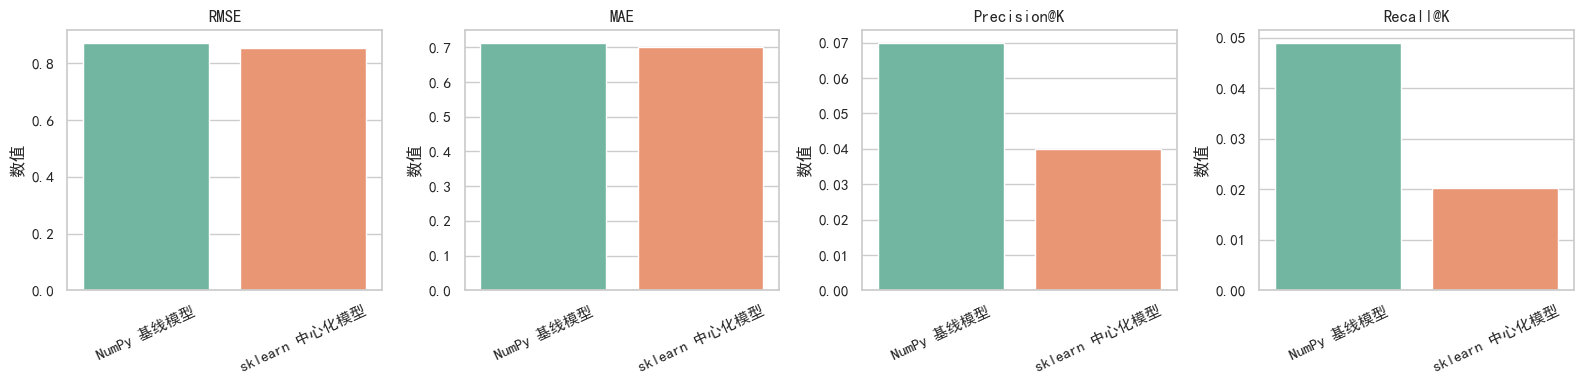

In [4]:
metric_labels = ['RMSE', 'MAE', 'Precision@K', 'Recall@K']
plot_source = comparison.copy()
plot_source.attrs = {}
plot_df = plot_source.melt(
    id_vars=['algorithm'],
    value_vars=metric_labels,
    var_name='指标',
    value_name='数值',
)
plot_df['模型'] = plot_df['algorithm'].map({
    BASELINE_ALGORITHM: 'NumPy 基线模型',
    SKLEARN_ALGORITHM: 'sklearn 中心化模型',
})

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metric_labels):
    current = plot_df[plot_df['指标'] == metric]
    sns.barplot(data=current, x='模型', y='数值', ax=ax, hue='模型', palette='Set2', legend=False)
    ax.set_title(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 5. 邻居数量 top_k 敏感性分析

协同过滤模型通常会受到邻居数量影响。这里测试 `top_k = 5, 10, 20, 40` 四组参数，观察不同模型在误差和推荐命中率上的变化。

In [5]:
sensitivity = sensitivity_analysis(
    matrix,
    top_k_values=(5, 10, 20, 40),
    top_n=experiment_config['推荐列表长度 Top-N'],
    test_size=experiment_config['测试集比例'],
    random_state=experiment_config['随机种子'],
    relevance_threshold=4.0,
    user_ids=eval_user_ids,
    algorithms=algorithms,
)

sensitivity_display = sensitivity.rename(columns=column_names)
display(sensitivity_display)

,模型,邻居数量,推荐数量,评估用户数,测试评分数,RMSE,MAE,Precision@K,Recall@K
0,baseline_numpy_item_cf,5,10,20,593,0.884880,0.722981,0.030,0.015239
1,baseline_numpy_item_cf,10,10,20,593,0.873668,0.720092,0.045,0.036601
2,baseline_numpy_item_cf,20,10,20,593,0.872365,0.713135,0.070,0.049008
3,baseline_numpy_item_cf,40,10,20,593,0.890805,0.736859,0.070,0.039263
4,sklearn_centered_item_cf,5,10,20,593,0.880942,0.709014,0.045,0.029709
5,sklearn_centered_item_cf,10,10,20,593,0.863147,0.707997,0.060,0.027742
6,sklearn_centered_item_cf,20,10,20,593,0.853986,0.701478,0.040,0.020280
7,sklearn_centered_item_cf,40,10,20,593,0.862422,0.710764,0.020,0.007733


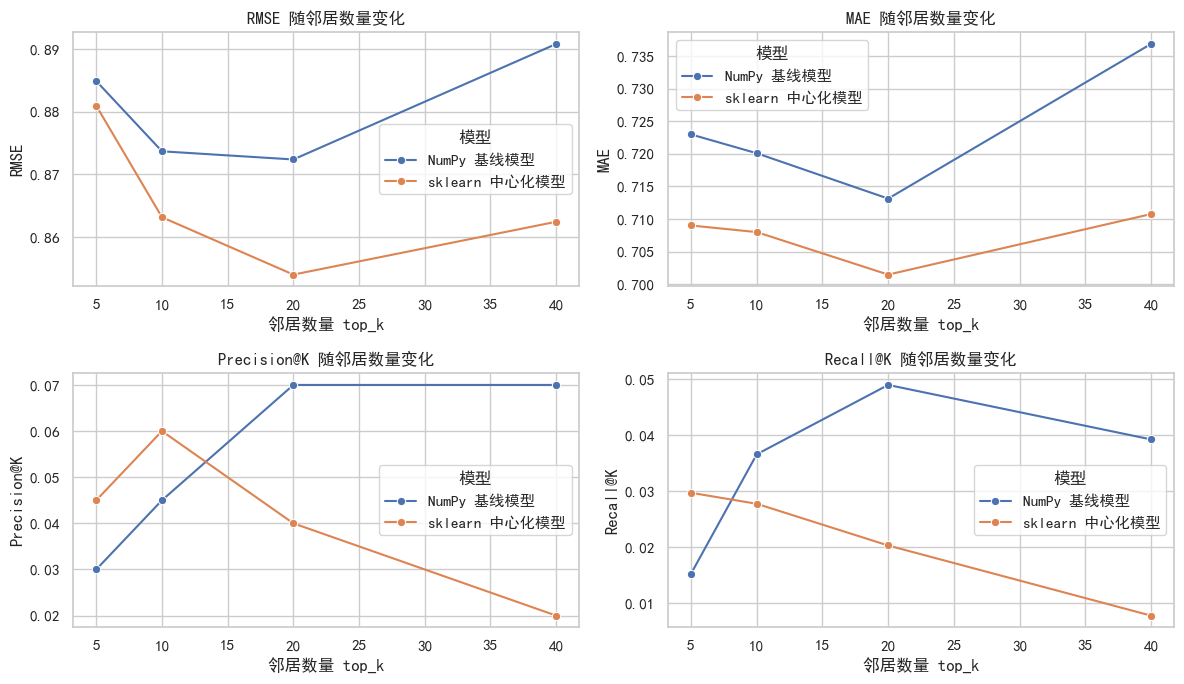

In [6]:
sensitivity_plot = sensitivity.copy()
sensitivity_plot['模型'] = sensitivity_plot['algorithm'].map({
    BASELINE_ALGORITHM: 'NumPy 基线模型',
    SKLEARN_ALGORITHM: 'sklearn 中心化模型',
})

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
axes = axes.ravel()
for ax, metric in zip(axes, metric_labels):
    sns.lineplot(
        data=sensitivity_plot,
        x='top_k_neighbors',
        y=metric,
        hue='模型',
        marker='o',
        ax=ax,
    )
    ax.set_title(f'{metric} 随邻居数量变化')
    ax.set_xlabel('邻居数量 top_k')
plt.tight_layout()
plt.show()

## 6. 指定用户推荐案例

选取一个样例用户，分别输出两个模型的 Top-10 推荐电影。该部分可用于报告中解释模型是如何为具体用户生成推荐结果的。

In [7]:
sample_user = eval_user_ids[0]
movie_title_map = load_movie_title_map(project_root)

case_tables = []
for algorithm in algorithms:
    recommendations = recommend_for_user(
        train_matrix=train_matrix,
        user_id=sample_user,
        algorithm=algorithm,
        top_k_neighbors=20,
        top_n=10,
    )
    table = attach_movie_titles(recommendations, movie_title_map)
    table.insert(0, '模型', algorithm)
    case_tables.append(table)

case_recommendations = pd.concat(case_tables, ignore_index=True)
case_recommendations = case_recommendations.rename(columns={
    'movieId': '电影ID',
    'title': '电影标题',
    'pred_rating': '预测评分',
})
print('样例用户：', sample_user)
display(case_recommendations)

样例用户： 1


,模型,电影ID,电影标题,预测评分
0,baseline_numpy_item_cf,4878,Donnie Darko (2001),4.909863
1,baseline_numpy_item_cf,68358,Star Trek (2009),4.906412
2,baseline_numpy_item_cf,91529,"Dark Knight Rises, The (2012)",4.870069
3,baseline_numpy_item_cf,54272,"Simpsons Movie, The (2007)",4.859397
4,baseline_numpy_item_cf,778,Trainspotting (1996),4.859047
5,baseline_numpy_item_cf,4011,Snatch (2000),4.858327
6,baseline_numpy_item_cf,1221,"Godfather: Part II, The (1974)",4.854420
7,baseline_numpy_item_cf,7361,Eternal Sunshine of the Spotless Mind (2004),4.846946
8,baseline_numpy_item_cf,6711,Lost in Translation (2003),4.845205
9,baseline_numpy_item_cf,111659,Maleficent (2014),4.838988


## 7. 实验结论记录

- `baseline_numpy_item_cf` 是手写 NumPy 基线模型，直接基于原始评分矩阵计算物品相似度。
- `sklearn_centered_item_cf` 使用 `scikit-learn` 计算余弦相似度，并通过用户均值中心化减少不同用户打分尺度差异。
- 两个模型已经在同一份训练/测试划分上进行比较，结果表和图表可直接用于技术报告的“实验结果与分析”部分。
- 当前 Notebook 默认使用 20 个用户做快速实验；如果需要最终实验结论，可以把 `eval_user_count` 改为 `None` 后重新运行。